In [85]:
!pwd

#!conda install -n divtel -c conda-forge "matplotlib<3.10"

# or pip
#!pip install "matplotlib<3.10"
#!y

/Users/macbook/divtel/MAGIC+LSTs


In [86]:
!y

/bin/bash: y: command not found


In [87]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%reload_ext autoreload
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import sys
from ipywidgets import interactive, FloatSlider, interact, fixed
from divtel import *
from adjustText import adjust_text

import copy
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroplan.plots import plot_sky
from astroplan import FixedTarget
#from . import utils
#from .const import COLORS
#from . import pointing

from matplotlib.transforms import Affine2D
from astropy.visualization.wcsaxes import SphericalCircle

import healpy as hp
import tqdm

#!jupyter labextension install @jupyter-widgets/jupyterlab-manager

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The Idea is to have two notebooks, one for MST configuration confronting just one altitude and the other for them changing with zenith
This one should be just for one altitude 

## LOAD CTA CONFIG

In [88]:
cta = CTA_Info('north')

Observer         :  CTA North
Location         :  Roque de los Muchachos , (5327.28509212, -1718.7771125, 3051.78673275) km
Observation time :  2025-09-24T18:24:00.563


In [89]:
# Note that if the radius is in meters, 
# you can set LoadConfig(file, radius="meters")
# defalut is in degrees

array = LoadConfig("/Users/macbook/divtel/MAGIC+LSTs.txt", frame=cta)


## Check configuration table

In [90]:
array.table.units = "deg"
array.table


id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,-70.91,-52.35,45.0,0.000,0.000,90.000,28.000,2.250,15.921,1.000,-0.000,0.000,51.97
2,-35.28,65.92,32.5,0.000,0.000,90.000,28.000,2.250,15.921,1.000,-0.000,0.000,123.05
3,75.31,50.21,28.2,0.000,0.000,90.000,28.000,2.150,14.536,1.000,-0.000,0.000,142.76
4,30.88,-63.78,32.8,0.000,0.000,90.000,28.000,2.150,14.536,1.000,-0.000,0.000,51.30
5,-23.51,-192.01,43.25,0.000,0.000,90.000,17.000,1.750,9.627,1.000,-0.000,0.000,136.17
6,-94.03,-144.07,44.4,0.000,0.000,90.000,17.000,1.750,9.627,1.000,-0.000,0.000,115.50


In [91]:
table=array.table

## Check the telescope spatial distribution
This is useful to pick the groups

In [92]:
array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,-70.91,-52.35,45.0,0.000,0.000,90.000,28.000,2.250,15.921,1.000,-0.000,0.000,51.97
2,-35.28,65.92,32.5,0.000,0.000,90.000,28.000,2.250,15.921,1.000,-0.000,0.000,123.05
3,75.31,50.21,28.2,0.000,0.000,90.000,28.000,2.150,14.536,1.000,-0.000,0.000,142.76
4,30.88,-63.78,32.8,0.000,0.000,90.000,28.000,2.150,14.536,1.000,-0.000,0.000,51.30
5,-23.51,-192.01,43.25,0.000,0.000,90.000,17.000,1.750,9.627,1.000,-0.000,0.000,136.17
6,-94.03,-144.07,44.4,0.000,0.000,90.000,17.000,1.750,9.627,1.000,-0.000,0.000,115.50


This is the whole telescope array hFoV maybe? (ask)

In [93]:
array.hFoV(m_cut=3) 

6it [00:01,  5.48it/s]


(14.582727085544024, 5.302158273381295)

In [94]:
#array.hFoV(m_cut=3)

## Grouping telescopes

# THE FIELD OF VIEW

## GRAPHING MULTIPLICITY AND FOV to understand what is going on 

In [95]:
array.hFoV()[0]

6it [00:00,  6.62it/s]


15.946579259012168

The barycenter -19.59
The barycenter -56.01333333333333
The barycenter 37.69166666666667


6it [00:00,  6.71it/s]


(16.62850534574624, 4.813091482649842)


6it [00:00,  7.25it/s]
6it [00:00,  6.94it/s]


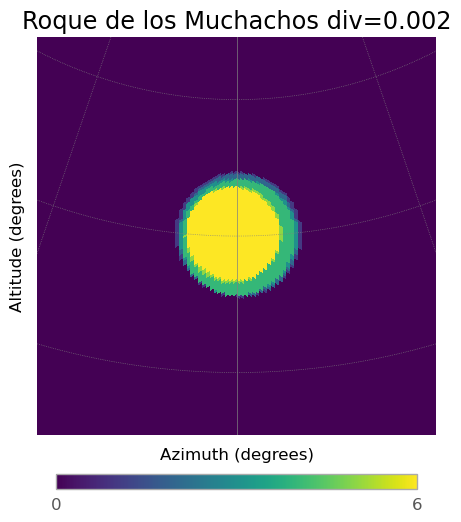

In [102]:
array.divergent_pointing(0.002, az=0,alt=70)
print(array.hFoV())
array.multiplicity_plot()

The barycenter -19.59
The barycenter -56.01333333333333
The barycenter 37.69166666666667


6it [00:00,  6.94it/s]


(17.861217887150143, 4.486784140969163)


6it [00:00,  7.20it/s]
6it [00:00,  6.84it/s]


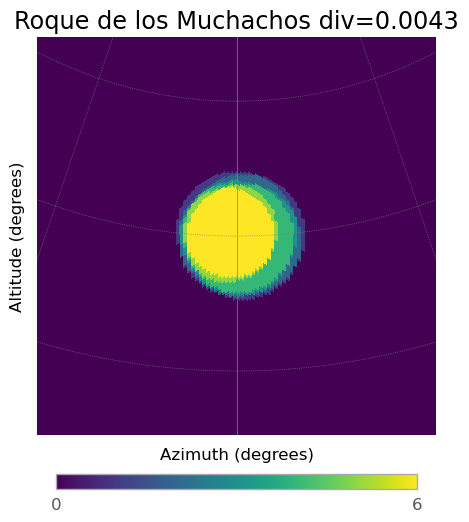

In [103]:
array.divergent_pointing(0.0043, az=0,alt=70)
print(array.hFoV())
array.multiplicity_plot()

The barycenter -19.59
The barycenter -56.01333333333333
The barycenter 37.69166666666667


6it [00:00,  6.78it/s]


(20.300415043545097, 3.948966408268734)


6it [00:00,  6.92it/s]
6it [00:00,  6.57it/s]


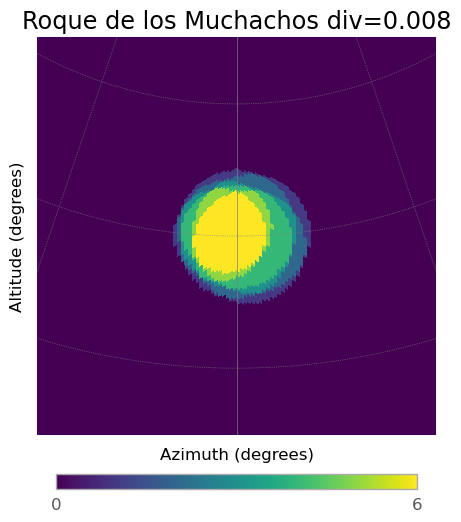

In [104]:
array.divergent_pointing(0.008, az=0,alt=70)
print(array.hFoV())
array.multiplicity_plot()

The barycenter -19.59
The barycenter -56.01333333333333
The barycenter 37.69166666666667


6it [00:00,  6.01it/s]


(23.080575243307088, 3.4681818181818183)


6it [00:00,  6.87it/s]
6it [00:00,  6.78it/s]


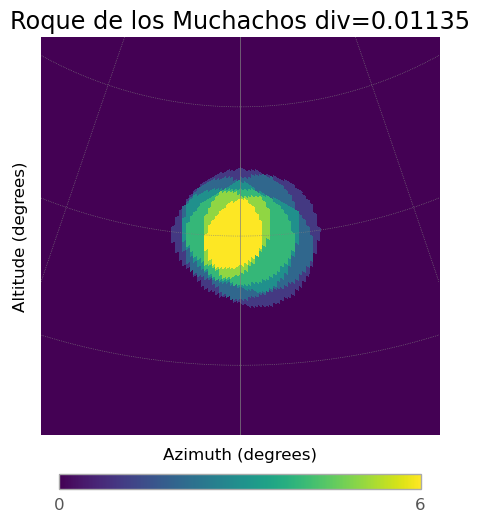

In [105]:
array.divergent_pointing(0.01135, az=0,alt=70)
print(array.hFoV())
array.multiplicity_plot()

The barycenter -19.59
The barycenter -56.01333333333333
The barycenter 37.69166666666667


6it [00:00,  6.04it/s]


(25.795165627036955, 3.108795119471276)


6it [00:00,  7.13it/s]
6it [00:00,  6.83it/s]


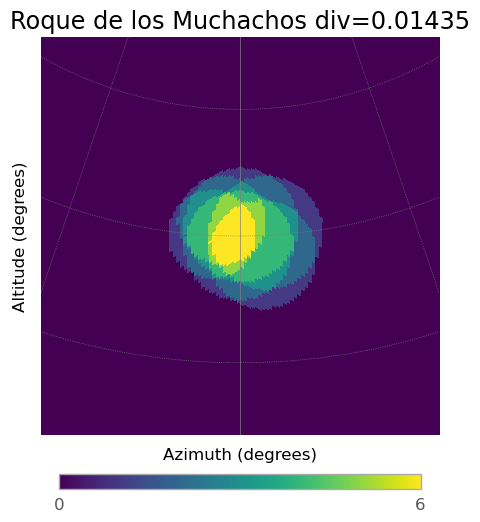

In [107]:
array.divergent_pointing(0.01435, az=0,alt=70)
print(array.hFoV())
array.multiplicity_plot()